Loaded dataset from: heart.csv
Shape: (1025, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First rows:
 age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
  52    1   0       125   212    0        1      168      0      1.0      2   2     3       0
  53    1   0       140   203    1        0      155      1      3.1      0   0     3       0
  70    1   0       145   174    0        1      125      1      2.6      0   0     3       0
  61    1   0       148   203    0        1      161      0      0.0      2   1     3       0
  62    0   0       138   294    1        1      106      0      1.9      1   3     2       0

Target distribution:
target
1    526
0    499


/Users/shadmanshakib/All work/Fast_API/Diabetic_de/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/shadmanshakib/All work/Fast_API/Diabetic_de/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/shadmanshakib/All work/Fast_API/Diabetic_de/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning


Best parameters found: {'log_reg__C': 0.1, 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}
Best cross-validated ROC-AUC: 0.9159

--- Test Set Performance ---
Accuracy : 0.8098
Precision: 0.7619
Recall   : 0.9143
F1-Score : 0.8312
ROC-AUC  : 0.9296

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.70      0.78       100
           1       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



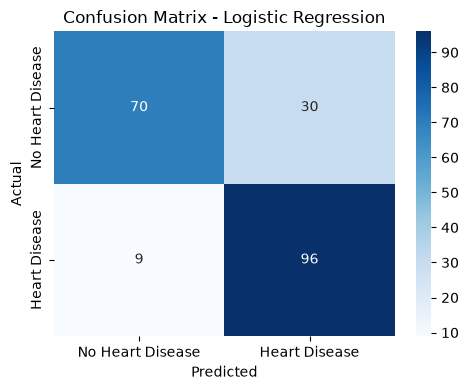

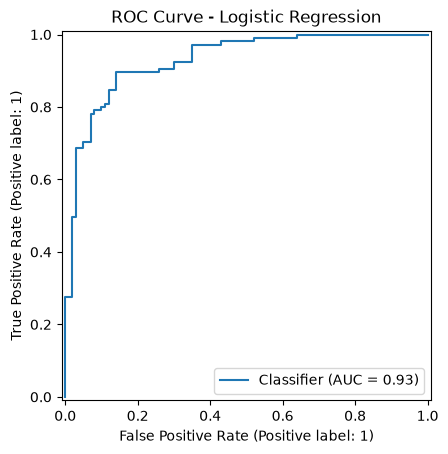


Feature Coefficients (sorted by importance):
     Feature  Coefficient
2         cp     0.757738
1        sex    -0.663468
11        ca    -0.653721
9    oldpeak    -0.536752
8      exang    -0.480916
12      thal    -0.456686
7    thalach     0.379649
10     slope     0.330777
3   trestbps    -0.308414
4       chol    -0.222219
6    restecg     0.142494
0        age    -0.125453
5        fbs    -0.013492


/var/folders/9d/cj_zyvdn30v3725ykpj9k1cm0000gn/T/ipykernel_59747/763845006.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x="Coefficient", y="Feature", palette="viridis")


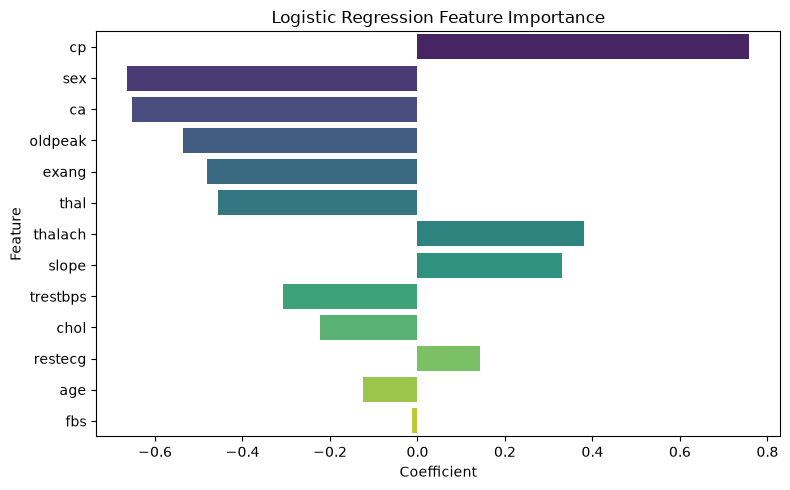

Model saved to: heart_disease_model.joblib


In [ ]:
from pydantic import BaseModel, Field, conint, confloat


class HeartInput(BaseModel):
    """
    Input schema for a single patient's data.
    Field names and order match the feature columns the
    model was trained on (all columns in heart.csv except 'target').
    """
    age: conint(ge=1, le=120) = Field(
        ..., example=52, description="Age in years"
    )
    sex: conint(ge=0, le=1) = Field(
        ..., example=1, description="Sex (1 = male, 0 = female)"
    )
    cp: conint(ge=0, le=3) = Field(
        ..., example=0, description="Chest pain type (0-3, 4 possible values)"
    )
    trestbps: conint(ge=0, le=300) = Field(
        ..., example=125, description="Resting blood pressure (mm Hg)"
    )
    chol: conint(ge=0, le=700) = Field(
        ..., example=212, description="Serum cholesterol (mg/dl)"
    )
    fbs: conint(ge=0, le=1) = Field(
        ..., example=0, description="Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)"
    )
    restecg: conint(ge=0, le=2) = Field(
        ..., example=1, description="Resting electrocardiographic results (0, 1, 2)"
    )
    thalach: conint(ge=0, le=250) = Field(
        ..., example=168, description="Maximum heart rate achieved"
    )
    exang: conint(ge=0, le=1) = Field(
        ..., example=0, description="Exercise induced angina (1 = yes, 0 = no)"
    )
    oldpeak: confloat(ge=0.0, le=10.0) = Field(
        ..., example=1.0, description="ST depression induced by exercise relative to rest"
    )
    slope: conint(ge=0, le=2) = Field(
        ..., example=2, description="Slope of the peak exercise ST segment (0-2)"
    )
    ca: conint(ge=0, le=3) = Field(
        ..., example=2, description="Number of major vessels (0-3) colored by flourosopy"
    )
    thal: conint(ge=0, le=2) = Field(
        ..., example=2,
        description="Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect)"
    )

    class Config:
        json_schema_extra = {
            "example": {
                "age": 52,
                "sex": 1,
                "cp": 0,
                "trestbps": 125,
                "chol": 212,
                "fbs": 0,
                "restecg": 1,
                "thalach": 168,
                "exang": 0,
                "oldpeak": 1.0,
                "slope": 2,
                "ca": 2,
                "thal": 2
            }
        }


class PredictionOutput(BaseModel):
    """Response schema returned by /predict"""
    heart_disease: bool = Field(..., description="True if the model predicts heart disease, else False")
    probability: float = Field(..., description="Model's predicted probability of heart disease (0-1)")


class ModelInfo(BaseModel):
    """Response schema returned by /info"""
    model_type: str
    features: list[str]